In [1]:
import sys
!{sys.executable} -m pip install xgboost --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import datetime
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, max_error
import matplotlib.pyplot as plt
print('Imports OK')

Imports OK


Configuration

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_PATH         = r'C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Features\cpu_baseline_revised.csv'
NEW_BASELINE_PATH = r'C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\cpu_baseline_new.csv'

SERVER_IDS = [1, 2, 3]

# ── Working-hour window ────────────────────────────────────────────────────────
# The revised dataset flags working_hour = 1 for hours 09–17 on weekdays.
# WORK_END is 18 (exclusive upper bound) to match hour_of_day values 9..17.
WORK_START = 9
WORK_END   = 19          # hours 9,10,...,17  →  9 slots
WORK_HOURS = list(range(WORK_START, WORK_END))
HORIZON    = len(WORK_HOURS)
LOOKBACK   = 24

PRED_DATE_ACTUAL = pd.Timestamp('2026-06-10').date()
PRED_DATE_FUTURE = pd.Timestamp('2026-06-11').date()

TARGET_COLS = [f'cpu_t{h:02d}' for h in WORK_HOURS]
HOUR_LABELS = [f'{h}:00' for h in WORK_HOURS]

# ── Recency window (days of training history to use) ──────────────────────────
# Only train on the most recent N *working* days before the prediction date.
RECENCY_WINDOW = {
    1: 30,
    2: 30,
    3: 45,
}

BEST_PARAMS = dict(
    n_estimators     = 800,
    max_depth        = 5,
    learning_rate    = 0.03,
    subsample        = 0.80,
    colsample_bytree = 0.80,
    min_child_weight = 3,
    reg_lambda       = 2.0,
    tree_method      = 'hist',
    random_state     = 42,
)
print('Config ready.')
print(f'Working hours : {WORK_HOURS}  ({HORIZON} slots)')

Config ready.
Working hours : [9, 10, 11, 12, 13, 14, 15, 16, 17, 18]  (10 slots)


Load Data

In [4]:
df_raw = pd.read_csv(DATA_PATH)
df_raw['ts'] = pd.to_datetime(df_raw['ts'], format='mixed', utc=True)
df_raw = df_raw.sort_values(['host_id', 'ts']).reset_index(drop=True)

print('Servers :', df_raw['host_id'].unique())
print('Columns :', df_raw.columns.tolist())
print()
for sid in SERVER_IDS:
    sub = df_raw[df_raw['host_id'] == sid]
    print(f'  Server {sid} ({sub["hostName"].iloc[0]}): '
          f'{len(sub):,} rows  '
          f'{sub["ts"].min().date()} → {sub["ts"].max().date()}  '
          f'| working_hour=1 rows: {sub["working_hour"].sum():,}')

Servers : [1 2 3]
Columns : ['id', 'ts', 'host_id', 'cpu_usage_pct', 'memory_usage_pct', 'power_kw', 'status', 'hostName', 'inlet_temp_c', 'cpu_temp_c', 'processor_count', 'status_encoded', 'cpu_lag_1', 'cpu_lag_2', 'cpu_change', 'cpu_roll_mean_3', 'cpu_acceleration', 'cpu_volatility', 'memory_lag_1', 'cpu_memory_ratio', 'power_roll_mean_12', 'thermal_gradient', 'temp_rate_of_change', 'temp_roll_mean_12', 'cpu_per_kw', 'temp_per_cpu', 'resource_stress_index', 'timestamp_display', 'hour_of_day', 'is_weekend', 'working_hour']

  Server 1 (10.10.10.65): 24,750 rows  2026-04-02 → 2026-06-11  | working_hour=1 rows: 7,052
  Server 2 (10.10.10.150): 24,751 rows  2026-04-02 → 2026-06-11  | working_hour=1 rows: 7,052
  Server 3 (10.10.10.2): 24,751 rows  2026-04-02 → 2026-06-11  | working_hour=1 rows: 7,052


Regime Shift Diagnostic

Visualise the full daily CPU timeline per server so the regime shift is clearly visible and documented.  
Only working-hour rows (`working_hour == 1`) contribute to the daily mean, ensuring like-for-like comparison across days.

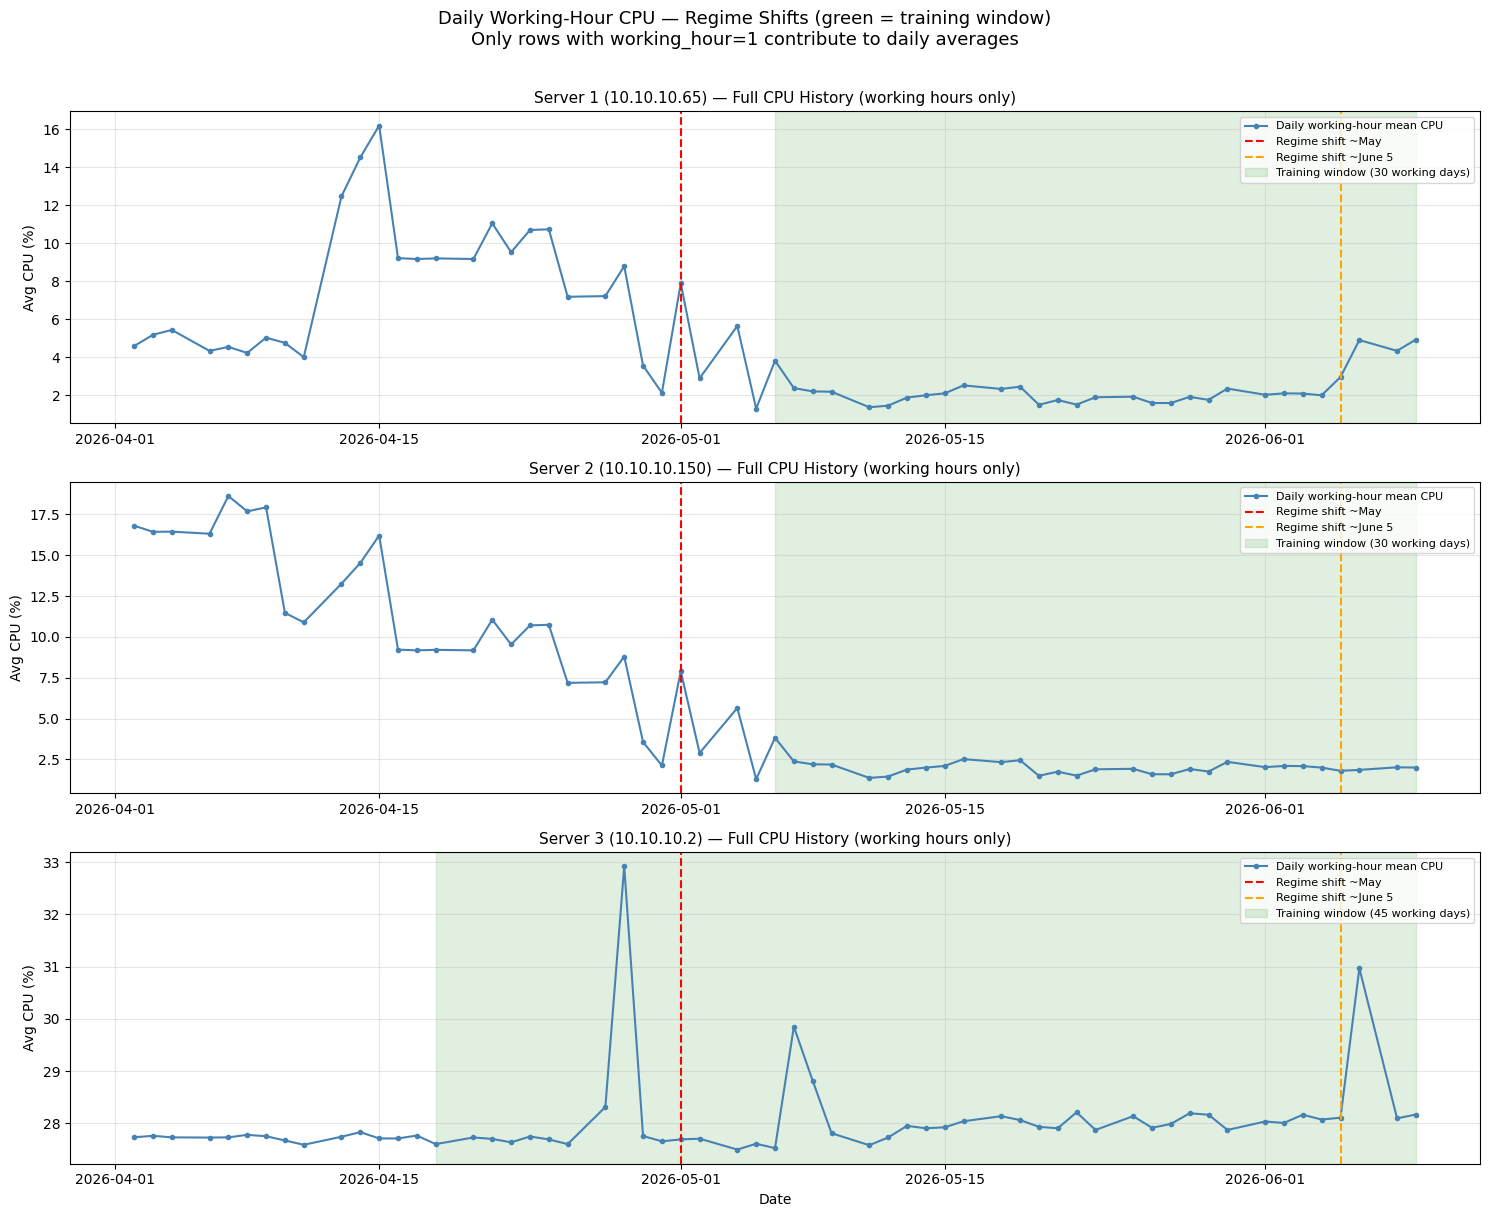

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

for row_idx, sid in enumerate(SERVER_IDS):
    sub  = df_raw[df_raw['host_id'] == sid].copy()
    name = sub['hostName'].iloc[0]

    # Use the dataset's working_hour flag to restrict to working hours
    work_sub = sub[sub['working_hour'] == 1].copy()
    work_sub['date'] = work_sub['ts'].dt.date

    daily = (
        work_sub.groupby('date')['cpu_usage_pct']
        .mean()
        .reset_index()
        .rename(columns={'cpu_usage_pct': 'cpu'})
    )
    daily['date'] = pd.to_datetime(daily['date'])
    daily = daily[daily['date'] < pd.Timestamp(PRED_DATE_ACTUAL)]

    window = RECENCY_WINDOW[sid]
    ax = axes[row_idx]
    ax.plot(daily['date'], daily['cpu'], color='steelblue', lw=1.5,
            marker='o', markersize=3, label='Daily working-hour mean CPU')
    ax.axvline(pd.Timestamp('2026-05-01'), color='red', lw=1.5,
               linestyle='--', label='Regime shift ~May')
    ax.axvline(pd.Timestamp('2026-06-05'), color='orange', lw=1.5,
               linestyle='--', label='Regime shift ~June 5')

    if len(daily) >= window:
        window_start = daily['date'].iloc[-window]
    else:
        window_start = daily['date'].iloc[0]
    ax.axvspan(window_start, daily['date'].iloc[-1],
               alpha=0.12, color='green',
               label=f'Training window ({window} working days)')

    ax.set_title(f'Server {sid} ({name}) — Full CPU History (working hours only)', fontsize=11)
    ax.set_ylabel('Avg CPU (%)')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.suptitle(
    'Daily Working-Hour CPU — Regime Shifts (green = training window)\n'
    'Only rows with working_hour=1 contribute to daily averages',
    fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Feature Engineering

In [6]:
def build_features(df_server: pd.DataFrame) -> pd.DataFrame:
    """Resample to 1-hour bins and engineer all model features.

    The revised dataset already carries `working_hour` and `is_weekend` at
    the raw row level.  We propagate them through the hourly resample by
    taking the *mode* (max works too since they are binary).  A third flag,
    `is_working_day`, is derived at the calendar-date level: a date is a
    working day only when at least one raw row in that date has
    `working_hour == 1`.
    """
    hourly = df_server.set_index('ts').resample('1h').agg(
        cpu_usage_pct         = ('cpu_usage_pct',         'mean'),
        cpu_min               = ('cpu_usage_pct',         'min'),
        cpu_max               = ('cpu_usage_pct',         'max'),
        cpu_std               = ('cpu_usage_pct',         'std'),
        memory_usage_pct      = ('memory_usage_pct',      'mean'),
        power_kw              = ('power_kw',              'mean'),
        cpu_temp_c            = ('cpu_temp_c',            'mean'),
        inlet_temp_c          = ('inlet_temp_c',          'mean'),
        resource_stress_index = ('resource_stress_index', 'mean'),
        # ── new: carry schedule flags through the resample ─────────────────
        working_hour          = ('working_hour',          'max'),
        is_weekend            = ('is_weekend',            'max'),
    ).dropna()

    # ── is_working_day: day-level flag ─────────────────────────────────────
    # Build a lookup: date → 1 if ANY raw row on that date has working_hour=1
    working_day_set = set(
        df_server[df_server['working_hour'] == 1]['ts'].dt.date.unique()
    )
    hourly['is_working_day'] = hourly.index.date
    hourly['is_working_day'] = hourly['is_working_day'].apply(
        lambda d: 1 if d in working_day_set else 0
    )

    # ── Time-index derived features ────────────────────────────────────────
    hourly['hour_of_day']   = hourly.index.hour
    hourly['day_of_week']   = hourly.index.dayofweek
    hourly['is_monday']     = (hourly['day_of_week'] == 0).astype(int)
    hourly['is_friday']     = (hourly['day_of_week'] == 4).astype(int)
    hourly['week_of_month'] = hourly.index.day.map(lambda d: (d - 1) // 7 + 1)
    hourly['hour_sin'] = np.sin(2 * np.pi * hourly['hour_of_day'] / 24)
    hourly['hour_cos'] = np.cos(2 * np.pi * hourly['hour_of_day'] / 24)
    hourly['dow_sin']  = np.sin(2 * np.pi * hourly['day_of_week'] / 7)
    hourly['dow_cos']  = np.cos(2 * np.pi * hourly['day_of_week'] / 7)

    # ── Lagged CPU features ────────────────────────────────────────────────
    for lag in range(1, LOOKBACK + 1):
        hourly[f'cpu_lag_{lag}'] = hourly['cpu_usage_pct'].shift(lag)

    hourly['cpu_lag_1w']       = hourly['cpu_usage_pct'].shift(168)
    hourly['cpu_lag_2w']       = hourly['cpu_usage_pct'].shift(336)
    hourly['cpu_vs_last_week'] = hourly['cpu_usage_pct'] - hourly['cpu_lag_1w']

    # ── Rolling statistics ─────────────────────────────────────────────────
    s = hourly['cpu_usage_pct'].shift(1)
    hourly['roll_mean_8h']  = s.rolling(8).mean()
    hourly['roll_mean_24h'] = s.rolling(24).mean()
    hourly['roll_std_8h']   = s.rolling(8).std()
    x6 = np.arange(6)
    hourly['cpu_trend_6h']  = s.rolling(6).apply(
        lambda y: np.polyfit(x6, y, 1)[0] if len(y) == 6 else np.nan, raw=True)

    # ── Previous-day anchor features ───────────────────────────────────────
    for h in [9, 12, 13, 14, 15, 16, 17]:
        hourly[f'prev_day_cpu_{h:02d}h'] = hourly['cpu_usage_pct'].shift(24 - 8 + h)
    hourly['prev_afternoon_mean'] = pd.concat(
        [hourly['cpu_usage_pct'].shift(24 - 8 + h) for h in range(13, 18)], axis=1
    ).mean(axis=1)
    hourly['prev_morning_mean'] = pd.concat(
        [hourly['cpu_usage_pct'].shift(24 - 8 + h) for h in range(9, 13)], axis=1
    ).mean(axis=1)

    # ── Ancillary metric lags ──────────────────────────────────────────────
    for col in ['memory_usage_pct', 'power_kw', 'cpu_temp_c',
                'inlet_temp_c', 'resource_stress_index']:
        hourly[f'{col}_lag1'] = hourly[col].shift(1)
        hourly[f'{col}_lag2'] = hourly[col].shift(2)

    return hourly.dropna()


# ── Feature column list ────────────────────────────────────────────────────────
FEATURE_COLS = (
    [f'cpu_lag_{i}' for i in range(1, LOOKBACK + 1)] +
    ['cpu_lag_1w', 'cpu_lag_2w', 'cpu_vs_last_week',
     'roll_mean_8h', 'roll_mean_24h', 'roll_std_8h', 'cpu_trend_6h',
     'cpu_min', 'cpu_max', 'cpu_std',
     'prev_afternoon_mean', 'prev_morning_mean',
     'prev_day_cpu_09h', 'prev_day_cpu_12h', 'prev_day_cpu_13h',
     'prev_day_cpu_14h', 'prev_day_cpu_15h', 'prev_day_cpu_16h', 'prev_day_cpu_17h',
     'memory_usage_pct_lag1', 'power_kw_lag1', 'cpu_temp_c_lag1',
     'inlet_temp_c_lag1', 'resource_stress_index_lag1',
     'memory_usage_pct_lag2', 'power_kw_lag2', 'cpu_temp_c_lag2',
     'inlet_temp_c_lag2', 'resource_stress_index_lag2',
     'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
     'hour_of_day', 'day_of_week', 'is_weekend', 'is_monday', 'is_friday',
     'week_of_month',
     # ── NEW: schedule-awareness features ──────────────────────────────
     'working_hour',      # 1 = this hour is a scheduled working hour
     'is_working_day',    # 1 = this calendar date is a working day (excl. holidays)
    ]
)
print(f'Feature count : {len(FEATURE_COLS)}')
print(f'New features  : working_hour, is_working_day')

Feature count : 65
New features  : working_hour, is_working_day


Build day dataset helperThe day-dataset builder now additionally records `is_working_day` at the day level so the training step can filter to working days only.

In [7]:
def build_day_dataset(hourly: pd.DataFrame) -> pd.DataFrame:
    """One row per calendar date: features from 08:00, targets = actual CPU 09–17.

    Each row also carries `is_working_day` so training can be restricted to
    days that actually have working-hour observations.
    """
    records = []
    for date in pd.Series(hourly.index.date).unique():
        day = hourly[hourly.index.date == date]

        # ── Prediction context: 08:00 row (or latest pre-work) ────────────
        pred_rows = day[day['hour_of_day'] == 8]
        if pred_rows.empty:
            continue
        pred_row = pred_rows.iloc[-1]

        # ── Targets: actual CPU for each working hour ─────────────────────
        targets, ok = {}, True
        for h in WORK_HOURS:
            t = day[day['hour_of_day'] == h]
            if t.empty:
                ok = False
                break
            targets[f'cpu_t{h:02d}'] = t.iloc[0]['cpu_usage_pct']
        if not ok:
            continue

        row = {col: pred_row[col] for col in FEATURE_COLS}
        row.update(targets)
        row['pred_date']      = date
        row['is_working_day'] = int(pred_row['is_working_day'])   # day-level flag
        records.append(row)
    return pd.DataFrame(records)


# ── Inference helpers ──────────────────────────────────────────────────────────
def get_8am_row(hourly, date):
    rows = hourly[(hourly.index.date == date) & (hourly['hour_of_day'] == 8)]
    return rows.iloc[-1] if not rows.empty else None


def get_working_actuals(hourly, date):
    day = hourly[hourly.index.date == date]
    return np.array([
        day[day['hour_of_day'] == h].iloc[0]['cpu_usage_pct']
        if not day[day['hour_of_day'] == h].empty else np.nan
        for h in WORK_HOURS
    ])


def get_best_pred_row(hourly, date):
    rows = hourly[(hourly.index.date == date) & (hourly['hour_of_day'] == 8)]
    if not rows.empty:
        return rows.iloc[-1], f'{date} 08:00'
    pre = hourly[(hourly.index.date == date) & (hourly['hour_of_day'] < 9)]
    if not pre.empty:
        r = pre.iloc[-1]
        return r, f'{date} {int(r["hour_of_day"]):02d}:00 (latest pre-work)'
    prev = date - datetime.timedelta(days=1)
    rows = hourly[(hourly.index.date == prev) & (hourly['hour_of_day'] == 8)]
    if not rows.empty:
        return rows.iloc[-1], f'{prev} 08:00 (prev-day proxy)'
    return None, 'No suitable prediction point found'


print('Helpers ready.')

Helpers ready.


Train

In [8]:
server_data    = {}
server_info    = {}
models_mid     = {}
models_lower   = {}
models_upper   = {}
datasets       = {}
train_windows  = {}
test_sets      = {}
predictions    = {}
pred_lower_all = {}
pred_upper_all = {}
metrics_all    = {}

for sid in SERVER_IDS:
    sub  = df_raw[df_raw['host_id'] == sid].copy()
    name = sub['hostName'].iloc[0]
    server_info[sid] = name
    window = RECENCY_WINDOW[sid]

    print(f"\n{'='*65}")
    print(f'SERVER {sid}  |  {name}  |  recency window = {window} working days')
    print(f"{'='*65}")

    # Build hourly features (now includes working_hour + is_working_day)
    hourly = build_features(sub)
    server_data[sid] = hourly

    ds = build_day_dataset(hourly)
    datasets[sid] = ds
    ds_str = ds.copy()
    ds_str['pred_date'] = ds_str['pred_date'].astype(str)

    # ── Filter: only working days before the prediction date ──────────────
    before_pred = ds_str[
        (ds_str['pred_date'] < str(PRED_DATE_ACTUAL)) &
        (ds_str['is_working_day'] == 1)          # <── NEW: exclude non-working days
    ]
    train_df = before_pred.iloc[-window:]        # last N working days
    train_windows[sid] = (train_df['pred_date'].iloc[0], train_df['pred_date'].iloc[-1])

    # ── Test set: June 10 only ────────────────────────────────────────────
    test_df = ds_str[ds_str['pred_date'] == str(PRED_DATE_ACTUAL)]

    print(f'  Full dataset days     : {len(ds)}')
    print(f'  Working days available: {int(ds_str[ds_str["pred_date"] < str(PRED_DATE_ACTUAL)]["is_working_day"].sum())}')
    print(f'  Training window       : {train_windows[sid][0]} → {train_windows[sid][1]}  ({len(train_df)} days)')
    print(f'  Training mean CPU     : {train_df[TARGET_COLS].mean().mean():.2f}%')
    print(f'  working_hour in train : {train_df["working_hour"].unique()}   '
          f'is_working_day in train: {train_df["is_working_day"].unique()}')

    X_train = train_df[FEATURE_COLS]
    Y_train = train_df[TARGET_COLS]
    test_sets[sid] = (test_df[FEATURE_COLS], test_df[TARGET_COLS], test_df)

    # ── Median (point forecast) ───────────────────────────────────────────
    mdl_mid = MultiOutputRegressor(XGBRegressor(**BEST_PARAMS), n_jobs=-1)
    mdl_mid.fit(X_train, Y_train)
    models_mid[sid] = mdl_mid

    # ── 10th percentile (lower bound) ────────────────────────────────────
    mdl_lo = MultiOutputRegressor(XGBRegressor(
        **{**BEST_PARAMS, 'objective': 'reg:quantileerror', 'quantile_alpha': 0.10}
    ), n_jobs=-1)
    mdl_lo.fit(X_train, Y_train)
    models_lower[sid] = mdl_lo

    # ── 90th percentile (upper bound) ────────────────────────────────────
    mdl_hi = MultiOutputRegressor(XGBRegressor(
        **{**BEST_PARAMS, 'objective': 'reg:quantileerror', 'quantile_alpha': 0.90}
    ), n_jobs=-1)
    mdl_hi.fit(X_train, Y_train)
    models_upper[sid] = mdl_hi

    # ── Evaluate on June 10 ───────────────────────────────────────────────
    if not test_df.empty:
        X_te = test_df[FEATURE_COLS]
        Y_te = test_df[TARGET_COLS]
        preds  = mdl_mid.predict(X_te)
        p_lo   = mdl_lo.predict(X_te)
        p_hi   = mdl_hi.predict(X_te)
        predictions[sid]    = preds
        pred_lower_all[sid] = p_lo
        pred_upper_all[sid] = p_hi

        rows = []
        for i, h in enumerate(WORK_HOURS):
            col = f'cpu_t{h:02d}'
            rows.append({
                'Hour': f'{h:02d}:00',
                'MAE' : mean_absolute_error(Y_te[col], preds[:, i]),
                'RMSE': np.sqrt(mean_squared_error(Y_te[col], preds[:, i])),
                'MAPE': np.mean(np.abs((Y_te[col].values - preds[:, i]) / Y_te[col].values)) * 100,
            })
        mdf = pd.DataFrame(rows)
        metrics_all[sid] = mdf
        print(f'  June 10 MAE  : {mdf["MAE"].mean():.3f}%')
        print(f'  June 10 MAPE : {mdf["MAPE"].mean():.2f}%')
    else:
        print('  June 10 not in dataset — training complete, no test eval.')

print('\nAll 3 servers trained.')


SERVER 1  |  10.10.10.65  |  recency window = 30 working days
  Full dataset days     : 55
  Working days available: 46
  Training window       : 2026-05-06 → 2026-06-09  (30 days)
  Training mean CPU     : 2.28%
  working_hour in train : [0.]   is_working_day in train: [1]
  June 10 MAE  : 0.656%
  June 10 MAPE : 13.11%

SERVER 2  |  10.10.10.150  |  recency window = 30 working days
  Full dataset days     : 55
  Working days available: 46
  Training window       : 2026-05-06 → 2026-06-09  (30 days)
  Training mean CPU     : 1.98%
  working_hour in train : [0.]   is_working_day in train: [1]
  June 10 MAE  : 0.775%
  June 10 MAPE : 26.78%

SERVER 3  |  10.10.10.2  |  recency window = 45 working days
  Full dataset days     : 55
  Working days available: 46
  Training window       : 2026-04-18 → 2026-06-09  (45 days)
  Training mean CPU     : 28.13%
  working_hour in train : [0.]   is_working_day in train: [1]
  June 10 MAE  : 0.164%
  June 10 MAPE : 0.58%

All 3 servers trained.


Average Working-Hour CPU Profile — Training Window

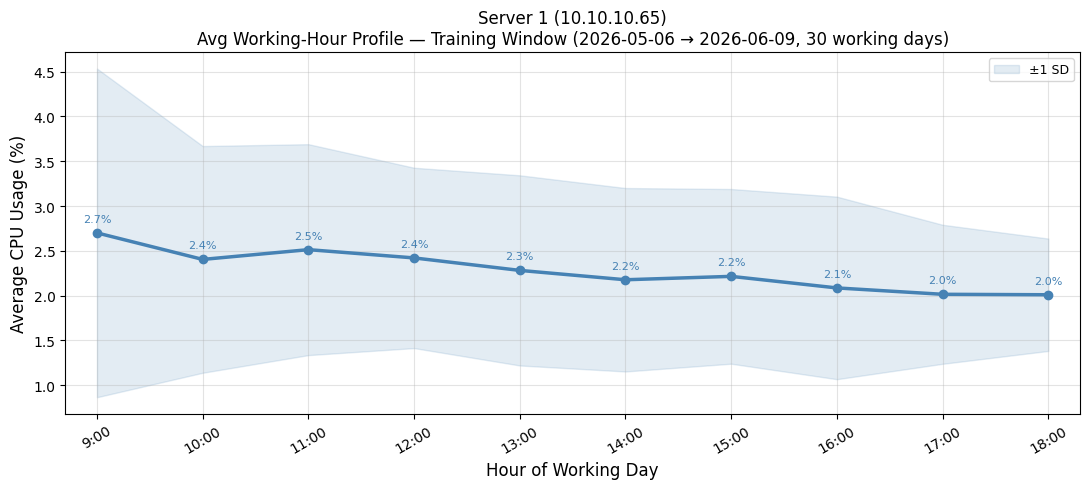

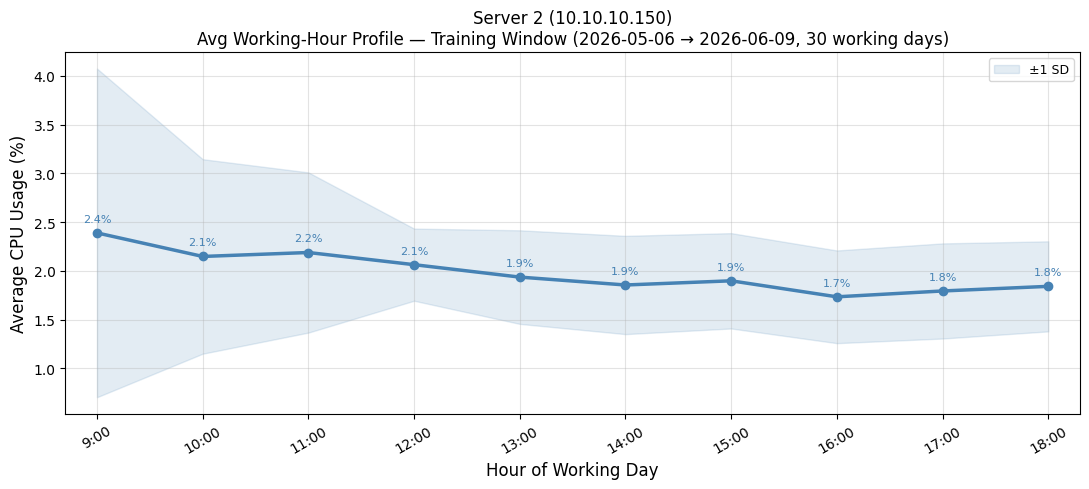

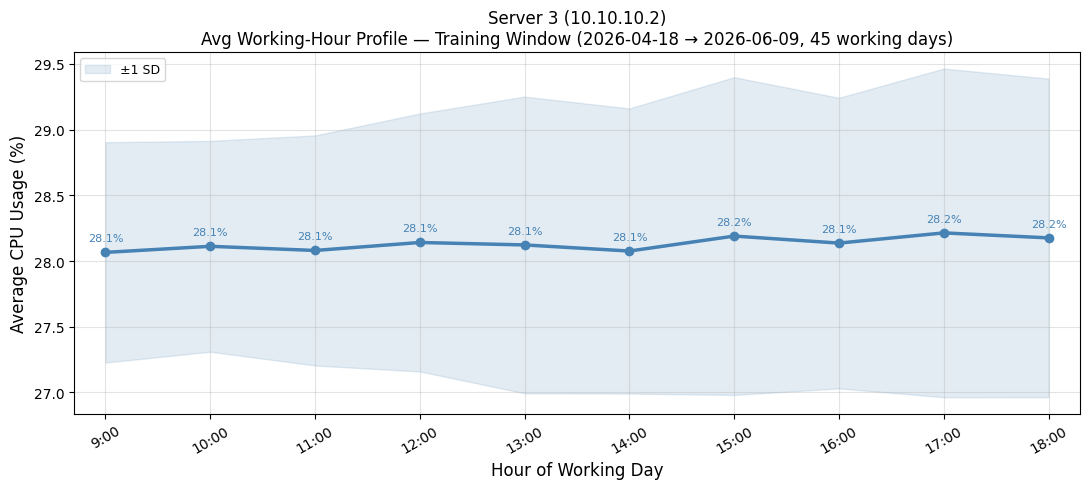

In [9]:
for sid in SERVER_IDS:
    ds   = datasets[sid].copy()
    ds['pred_date'] = ds['pred_date'].astype(str)
    name = server_info[sid]
    window = RECENCY_WINDOW[sid]

    before_pred = ds[
        (ds['pred_date'] < str(PRED_DATE_ACTUAL)) &
        (ds['is_working_day'] == 1)
    ]
    train_df = before_pred.iloc[-window:]

    avg_cpu = [train_df[f'cpu_t{h:02d}'].mean() for h in WORK_HOURS]
    std_cpu = [train_df[f'cpu_t{h:02d}'].std()  for h in WORK_HOURS]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(WORK_HOURS, avg_cpu, color='steelblue', marker='o', lw=2.5)
    ax.fill_between(
        WORK_HOURS,
        np.array(avg_cpu) - np.array(std_cpu),
        np.array(avg_cpu) + np.array(std_cpu),
        alpha=0.15, color='steelblue', label='±1 SD'
    )
    ax.set_xticks(WORK_HOURS)
    ax.set_xticklabels(HOUR_LABELS, rotation=30)
    ax.set_xlabel('Hour of Working Day', fontsize=12)
    ax.set_ylabel('Average CPU Usage (%)', fontsize=12)
    ax.set_title(
        f'Server {sid} ({name})\n'
        f'Avg Working-Hour Profile — Training Window '
        f'({train_windows[sid][0]} → {train_windows[sid][1]}, {window} working days)',
        fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.35)
    ax.set_xlim(WORK_HOURS[0] - 0.3, WORK_HOURS[-1] + 0.3)
    for xv, yv in zip(WORK_HOURS, avg_cpu):
        ax.annotate(f'{yv:.1f}%', (xv, yv), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8, color='steelblue')
    plt.tight_layout()
    plt.show()

June 11 - forecast with confidence band

Server 1 — 2026-06-11 04:00 (latest pre-work)
  working_hour=0  is_working_day=0  is_weekend=0


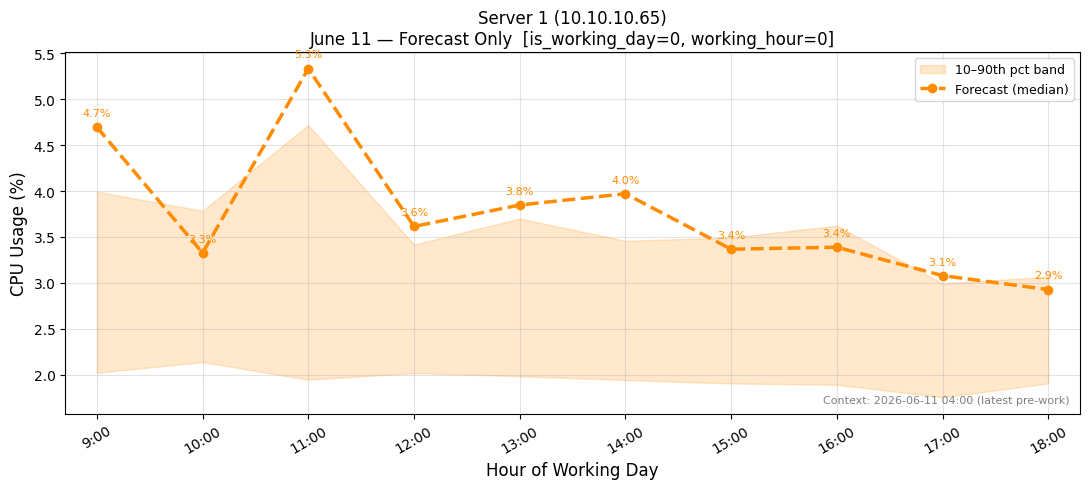

Server 2 — 2026-06-11 04:00 (latest pre-work)
  working_hour=0  is_working_day=0  is_weekend=0


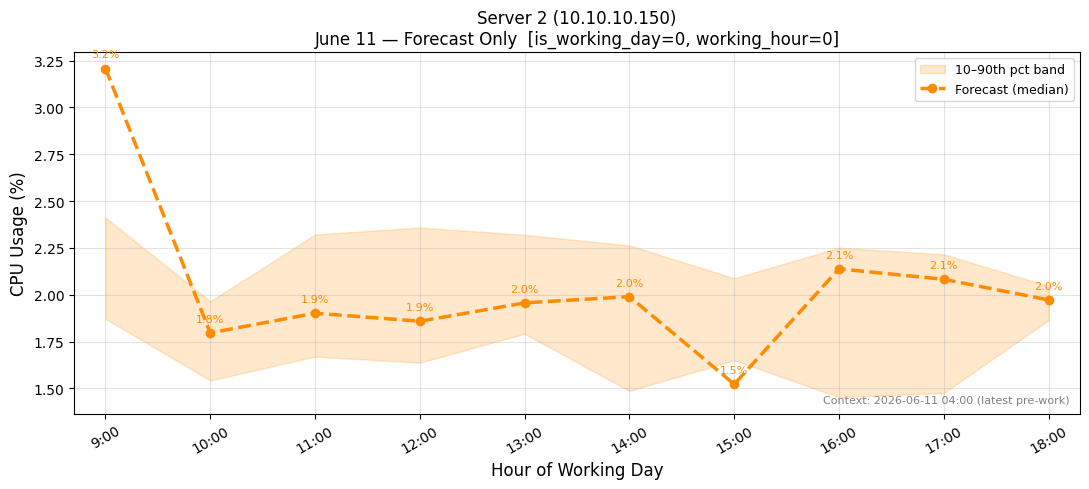

Server 3 — 2026-06-11 04:00 (latest pre-work)
  working_hour=0  is_working_day=0  is_weekend=0


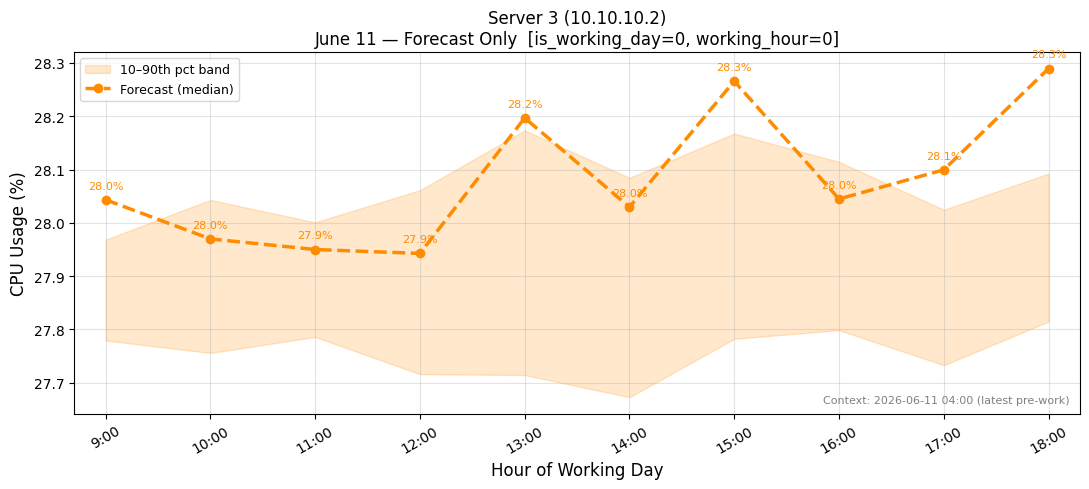

In [11]:
june11_forecasts = {}

for sid in SERVER_IDS:
    hourly = server_data[sid]
    name   = server_info[sid]

    pred_row, ctx_label = get_best_pred_row(hourly, PRED_DATE_FUTURE)
    if pred_row is None:
        print(f'Server {sid}: no prediction point found')
        continue

    # Report the schedule flags the model will see for June 11
    print(f'Server {sid} — {ctx_label}')
    print(f'  working_hour={int(pred_row["working_hour"])}  '
          f'is_working_day={int(pred_row["is_working_day"])}  '
          f'is_weekend={int(pred_row["is_weekend"])}')

    X_infer = pd.DataFrame([pred_row[FEATURE_COLS]])
    fc_mid  = models_mid[sid].predict(X_infer)[0]
    fc_lo   = models_lower[sid].predict(X_infer)[0]
    fc_hi   = models_upper[sid].predict(X_infer)[0]
    june11_forecasts[sid] = fc_mid

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.fill_between(WORK_HOURS, fc_lo, fc_hi,
                    alpha=0.2, color='darkorange', label='10–90th pct band')
    ax.plot(WORK_HOURS, fc_mid, color='darkorange', marker='o',
            lw=2.5, linestyle='--', label='Forecast (median)')
    ax.set_xticks(WORK_HOURS)
    ax.set_xticklabels(HOUR_LABELS, rotation=30)
    ax.set_xlabel('Hour of Working Day', fontsize=12)
    ax.set_ylabel('CPU Usage (%)', fontsize=12)
    ax.set_title(
        f'Server {sid} ({name})\n'
        f'June 11 — Forecast Only  '
        f'[is_working_day=0, working_hour=0]',
        fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.35)
    ax.set_xlim(WORK_HOURS[0] - 0.3, WORK_HOURS[-1] + 0.3)
    ax.text(0.99, 0.03, f'Context: {ctx_label}',
            transform=ax.transAxes, ha='right', fontsize=8, color='gray')
    for xv, yv in zip(WORK_HOURS, fc_mid):
        ax.annotate(f'{yv:.1f}%', (xv, yv), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8, color='darkorange')
    plt.tight_layout()
    plt.show()

June 11 Actual CPU (from new baseline)

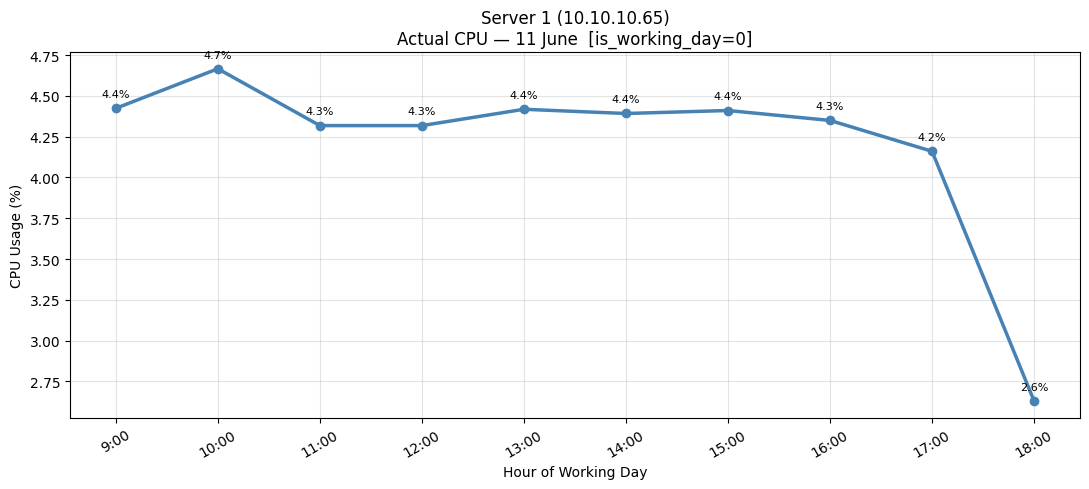

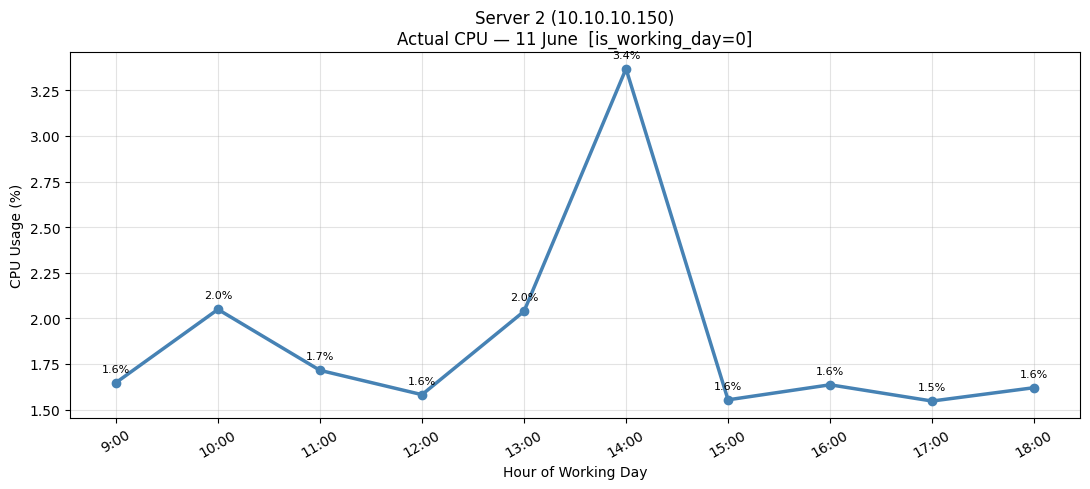

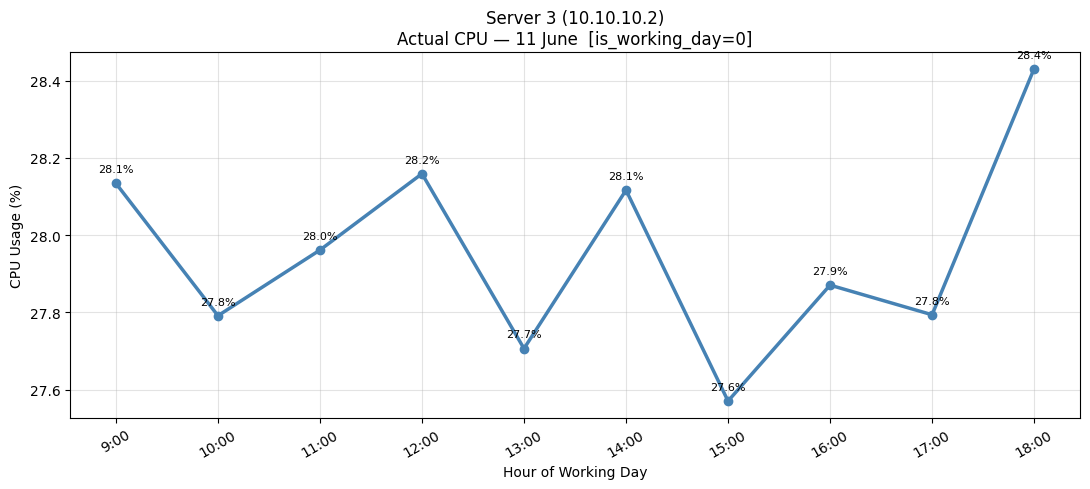

In [12]:
actual_df = pd.read_csv(NEW_BASELINE_PATH)
actual_df['ts'] = pd.to_datetime(actual_df['ts'], format='mixed', utc=True)
actual_df['ts'] = actual_df['ts'].dt.tz_localize(None)
TARGET_DATE = pd.Timestamp('2026-06-11').date()

actual_hourly = (
    actual_df.set_index('ts')
    .groupby('host_id')
    .resample('1H')['cpu_usage_pct']
    .mean()
    .reset_index()
)
actual_hourly['hour_of_day'] = actual_hourly['ts'].dt.hour
actual_june11 = {}

for sid in SERVER_IDS:
    server = actual_hourly[
        (actual_hourly['host_id'] == sid) &
        (actual_hourly['ts'].dt.date == TARGET_DATE) &
        (actual_hourly['hour_of_day'].isin(WORK_HOURS))
    ].sort_values('hour_of_day')

    cpu = [
        server[server['hour_of_day'] == h]['cpu_usage_pct'].iloc[0]
        if not server[server['hour_of_day'] == h].empty else np.nan
        for h in WORK_HOURS
    ]
    actual_june11[sid] = np.array(cpu)

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(WORK_HOURS, cpu, marker='o', lw=2.5, color='steelblue')
    ax.set_xticks(WORK_HOURS)
    ax.set_xticklabels(HOUR_LABELS, rotation=30)
    ax.set_xlabel('Hour of Working Day')
    ax.set_ylabel('CPU Usage (%)')
    ax.set_title(
        f'Server {sid} ({server_info[sid]})\n'
        f'Actual CPU — 11 June  [is_working_day=0]')
    ax.grid(True, alpha=0.35)
    for xv, yv in zip(WORK_HOURS, cpu):
        if not np.isnan(yv):
            ax.annotate(f'{yv:.1f}%', (xv, yv), textcoords='offset points',
                        xytext=(0, 8), ha='center', fontsize=8)
    plt.tight_layout()
    plt.show()

June 11 — Predicted vs Actual with Confidence Band

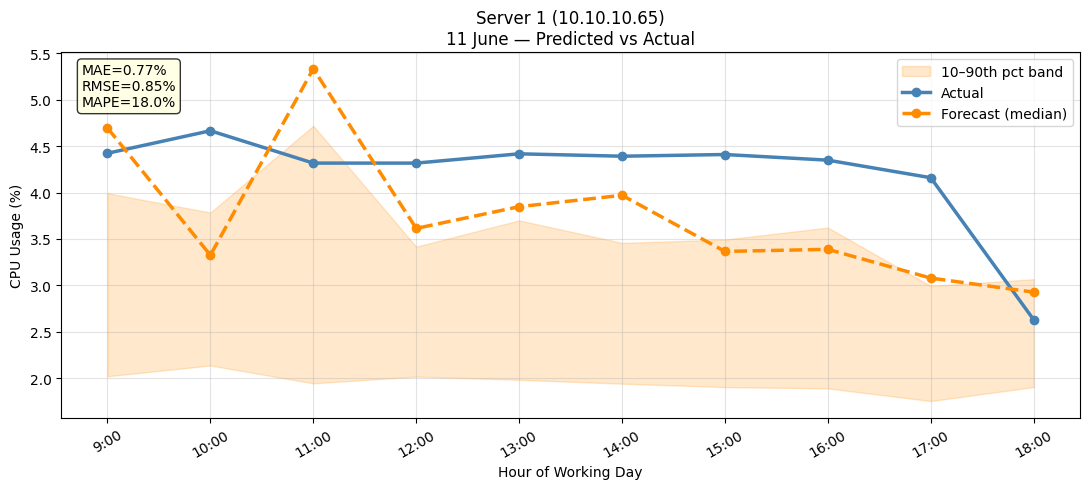

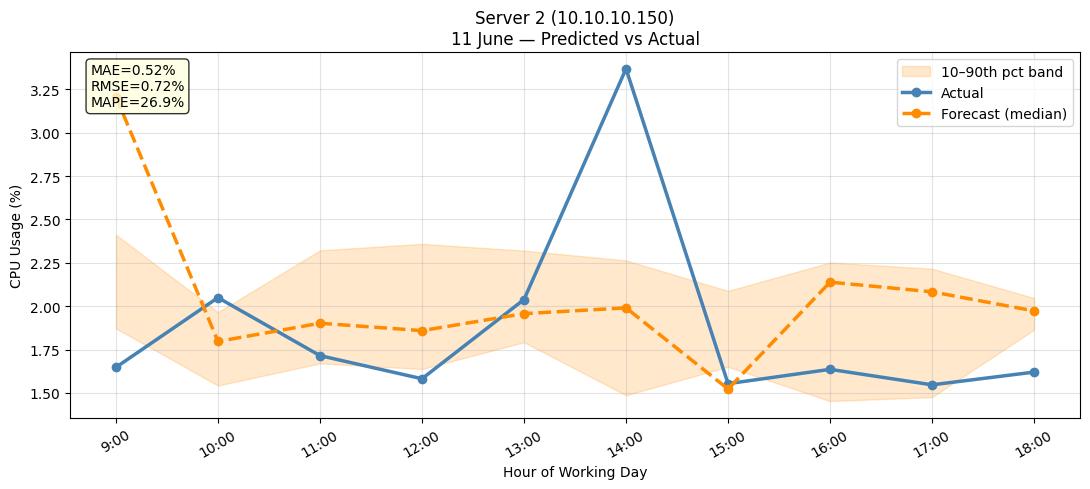

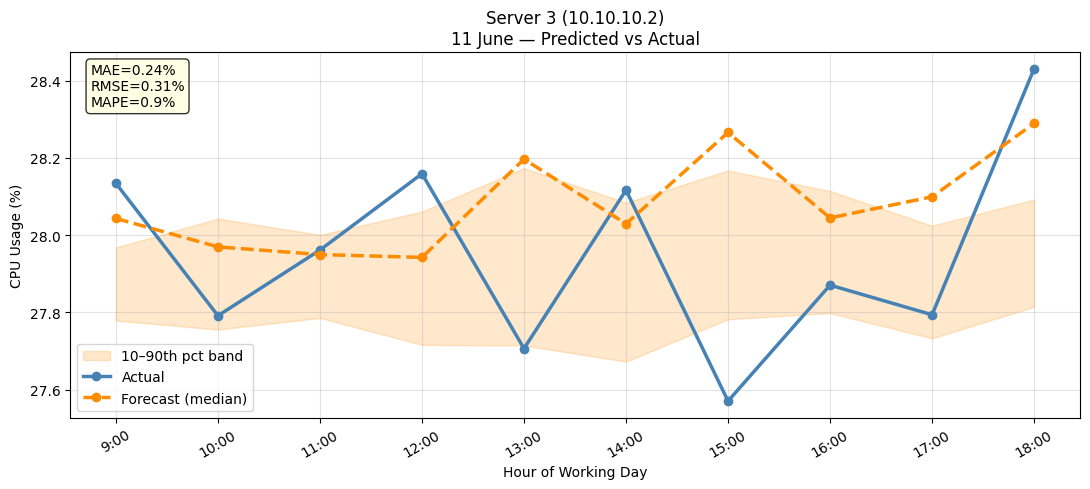

In [13]:
for sid in SERVER_IDS:
    pred   = june11_forecasts[sid]
    actual = actual_june11[sid]
    hourly = server_data[sid]
    name   = server_info[sid]

    pr, _ = get_best_pred_row(hourly, PRED_DATE_FUTURE)
    X_inf = pd.DataFrame([pr[FEATURE_COLS]])
    fc_lo = models_lower[sid].predict(X_inf)[0]
    fc_hi = models_upper[sid].predict(X_inf)[0]

    mask = ~np.isnan(actual)
    mae  = np.nanmean(np.abs(pred - actual))
    rmse = np.sqrt(np.nanmean((pred - actual) ** 2))
    mape = np.nanmean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.fill_between(WORK_HOURS, fc_lo, fc_hi,
                    alpha=0.2, color='darkorange', label='10–90th pct band')
    ax.plot(WORK_HOURS, actual, marker='o', lw=2.5,
            color='steelblue', label='Actual')
    ax.plot(WORK_HOURS, pred, marker='o', lw=2.5,
            color='darkorange', linestyle='--', label='Forecast (median)')
    ax.set_xticks(WORK_HOURS)
    ax.set_xticklabels(HOUR_LABELS, rotation=30)
    ax.set_xlabel('Hour of Working Day')
    ax.set_ylabel('CPU Usage (%)')
    ax.set_title(f'Server {sid} ({name})\n11 June — Predicted vs Actual')
    ax.legend()
    ax.grid(True, alpha=0.35)
    ax.text(0.02, 0.97,
            f'MAE={mae:.2f}%\nRMSE={rmse:.2f}%\nMAPE={mape:.1f}%',
            transform=ax.transAxes, va='top',
            bbox=dict(facecolor='lightyellow', alpha=0.8, boxstyle='round'))
    plt.tight_layout()
    plt.show()

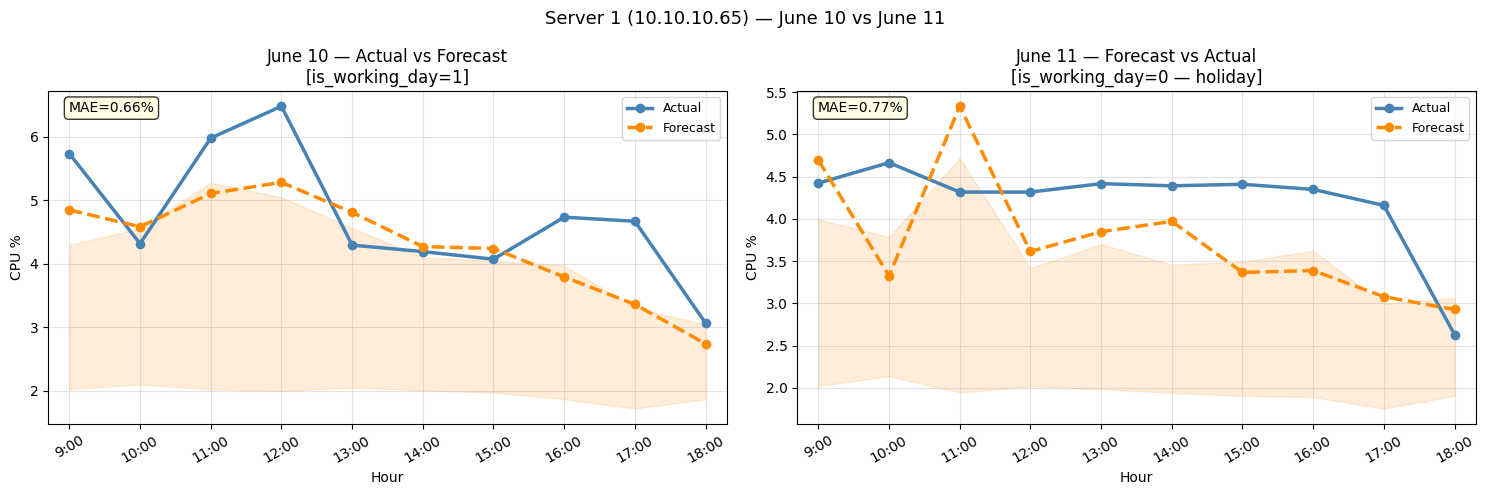

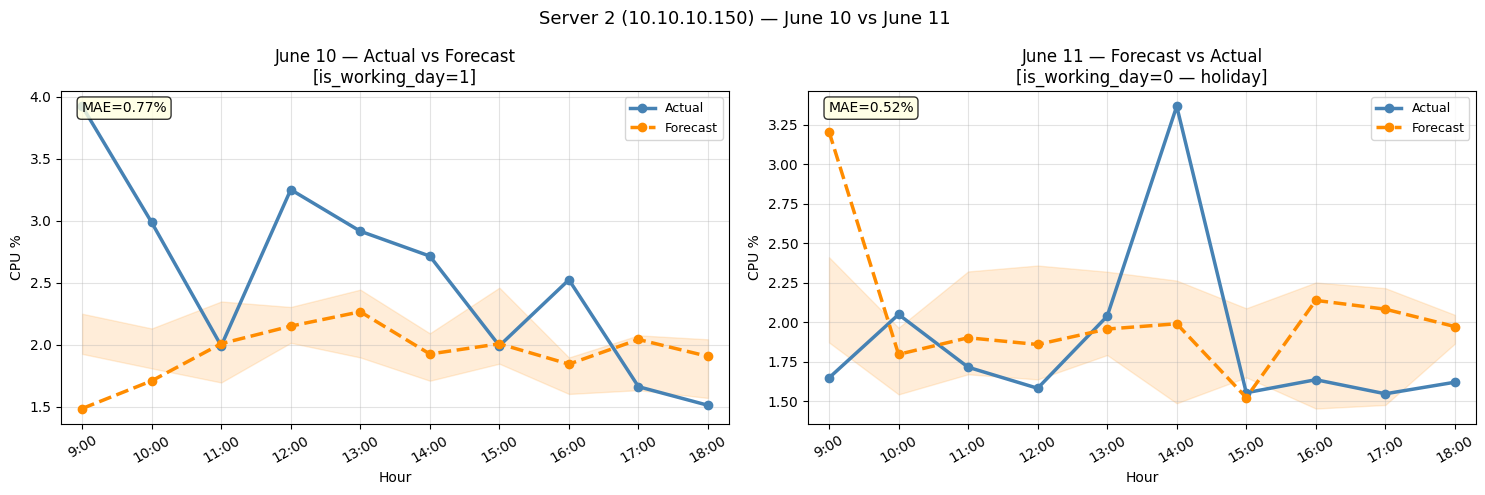

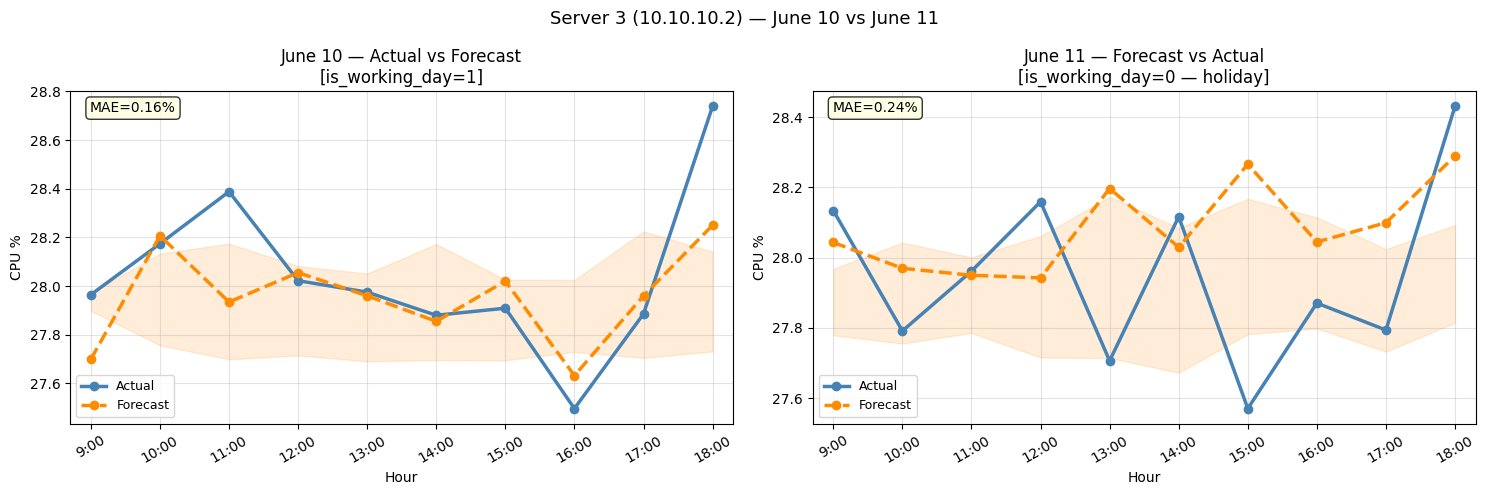

In [14]:
# June 10 vs June 11 Side-by-Side — All Servers
for sid in SERVER_IDS:
    hourly = server_data[sid]
    name   = server_info[sid]
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # ── June 10 ────────────────────────────────────────────────────────────
    ax10  = axes[0]
    pr10  = get_8am_row(hourly, PRED_DATE_ACTUAL)
    if pr10 is not None:
        X10   = pd.DataFrame([pr10[FEATURE_COLS]])
        fc10  = models_mid[sid].predict(X10)[0]
        lo10  = models_lower[sid].predict(X10)[0]
        hi10  = models_upper[sid].predict(X10)[0]
        act10 = get_working_actuals(hourly, PRED_DATE_ACTUAL)
        mae10 = np.nanmean(np.abs(fc10 - act10))
        ax10.fill_between(WORK_HOURS, lo10, hi10, alpha=0.15, color='darkorange')
        ax10.plot(WORK_HOURS, act10, color='steelblue', marker='o',
                  lw=2.5, label='Actual')
        ax10.plot(WORK_HOURS, fc10,  color='darkorange', marker='o',
                  lw=2.5, linestyle='--', label='Forecast')
        ax10.text(0.03, 0.97, f'MAE={mae10:.2f}%',
                  transform=ax10.transAxes, va='top',
                  bbox=dict(facecolor='lightyellow', alpha=0.8, boxstyle='round'))
    ax10.set_xticks(WORK_HOURS); ax10.set_xticklabels(HOUR_LABELS, rotation=30)
    ax10.set_xlabel('Hour', fontsize=10); ax10.set_ylabel('CPU %', fontsize=10)
    ax10.set_title('June 10 — Actual vs Forecast\n[is_working_day=1]', fontsize=12)
    ax10.legend(fontsize=9); ax10.grid(True, alpha=0.35)
    ax10.set_xlim(WORK_HOURS[0] - 0.3, WORK_HOURS[-1] + 0.3)

    # ── June 11 ────────────────────────────────────────────────────────────
    ax11 = axes[1]
    if sid in june11_forecasts and sid in actual_june11:
        fc11  = june11_forecasts[sid]
        act11 = actual_june11[sid]
        pr11, _ = get_best_pred_row(hourly, PRED_DATE_FUTURE)
        X11   = pd.DataFrame([pr11[FEATURE_COLS]])
        lo11  = models_lower[sid].predict(X11)[0]
        hi11  = models_upper[sid].predict(X11)[0]
        mae11 = np.nanmean(np.abs(fc11 - act11))
        ax11.fill_between(WORK_HOURS, lo11, hi11, alpha=0.15, color='darkorange')
        ax11.plot(WORK_HOURS, act11, color='steelblue', marker='o',
                  lw=2.5, label='Actual')
        ax11.plot(WORK_HOURS, fc11,  color='darkorange', marker='o',
                  lw=2.5, linestyle='--', label='Forecast')
        ax11.text(0.03, 0.97, f'MAE={mae11:.2f}%',
                  transform=ax11.transAxes, va='top',
                  bbox=dict(facecolor='lightyellow', alpha=0.8, boxstyle='round'))
    ax11.set_xticks(WORK_HOURS); ax11.set_xticklabels(HOUR_LABELS, rotation=30)
    ax11.set_xlabel('Hour', fontsize=10); ax11.set_ylabel('CPU %', fontsize=10)
    ax11.set_title('June 11 — Forecast vs Actual\n[is_working_day=0 — holiday]', fontsize=12)
    ax11.legend(fontsize=9); ax11.grid(True, alpha=0.35)
    ax11.set_xlim(WORK_HOURS[0] - 0.3, WORK_HOURS[-1] + 0.3)

    fig.suptitle(f'Server {sid} ({name}) — June 10 vs June 11', fontsize=13)
    plt.tight_layout()
    plt.show()


In [15]:
results = []
print('=' * 75)
print('FORECAST PERFORMANCE — 11 JUNE  (working_hour + is_working_day features)')
print('=' * 75)

for sid in SERVER_IDS:
    actual = actual_june11[sid]
    pred   = june11_forecasts[sid]
    mask   = ~np.isnan(actual)
    a, p   = actual[mask], pred[mask]

    mae    = mean_absolute_error(a, p)
    rmse   = np.sqrt(mean_squared_error(a, p))
    mape   = np.mean(np.abs((a - p) / a)) * 100
    r2     = r2_score(a, p)
    maxerr = max_error(a, p)

    results.append({
        'Server'       : sid,
        'Hostname'     : server_info[sid],
        'Train window' : f'{RECENCY_WINDOW[sid]} working days',
        'New features' : 'working_hour, is_working_day',
        'MAE'          : mae,
        'RMSE'         : rmse,
        'MAPE(%)'      : mape,
        'R²'           : r2,
        'MaxError'     : maxerr,
    })

    print(f'\nServer {sid} ({server_info[sid]}) — trained on last {RECENCY_WINDOW[sid]} working days')
    print(f'  New features : working_hour, is_working_day')
    print(f'  MAE          : {mae:.3f}%')
    print(f'  RMSE         : {rmse:.3f}%')
    print(f'  MAPE         : {mape:.2f}%')
    print(f'  R²           : {r2:.4f}')
    print(f'  Max Error    : {maxerr:.3f}%')

print('\n' + '=' * 75)
pd.DataFrame(results).round(3)

FORECAST PERFORMANCE — 11 JUNE  (working_hour + is_working_day features)

Server 1 (10.10.10.65) — trained on last 30 working days
  New features : working_hour, is_working_day
  MAE          : 0.771%
  RMSE         : 0.847%
  MAPE         : 18.02%
  R²           : -1.4632
  Max Error    : 1.340%

Server 2 (10.10.10.150) — trained on last 30 working days
  New features : working_hour, is_working_day
  MAE          : 0.516%
  RMSE         : 0.720%
  MAPE         : 26.95%
  R²           : -0.8608
  Max Error    : 1.560%

Server 3 (10.10.10.2) — trained on last 45 working days
  New features : working_hour, is_working_day
  MAE          : 0.239%
  RMSE         : 0.310%
  MAPE         : 0.86%
  R²           : -0.6151
  Max Error    : 0.695%



,Server,Hostname,Train window,New features,MAE,RMSE,MAPE(%),R²,MaxError
0,1,10.10.10.65,30 working days,"working_hour, is_working_day",0.771,0.847,18.024,-1.463,1.340
1,2,10.10.10.150,30 working days,"working_hour, is_working_day",0.516,0.720,26.947,-0.861,1.560
2,3,10.10.10.2,45 working days,"working_hour, is_working_day",0.239,0.310,0.859,-0.615,0.695
